In [1]:
from pathlib import Path
import pandas as pd

table_pkl_dim5 = Path("~/t7ssd/classification_results_consistent_features/dim5/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim5)


In [2]:
group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [3]:
df.columns


Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

In [4]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(2999.999, 36000.0]      900
(36000.0, 90000.0]       850
(194250.0, 1200000.0]    800
(90000.0, 194250.0]      650
Name: count, dtype: int64

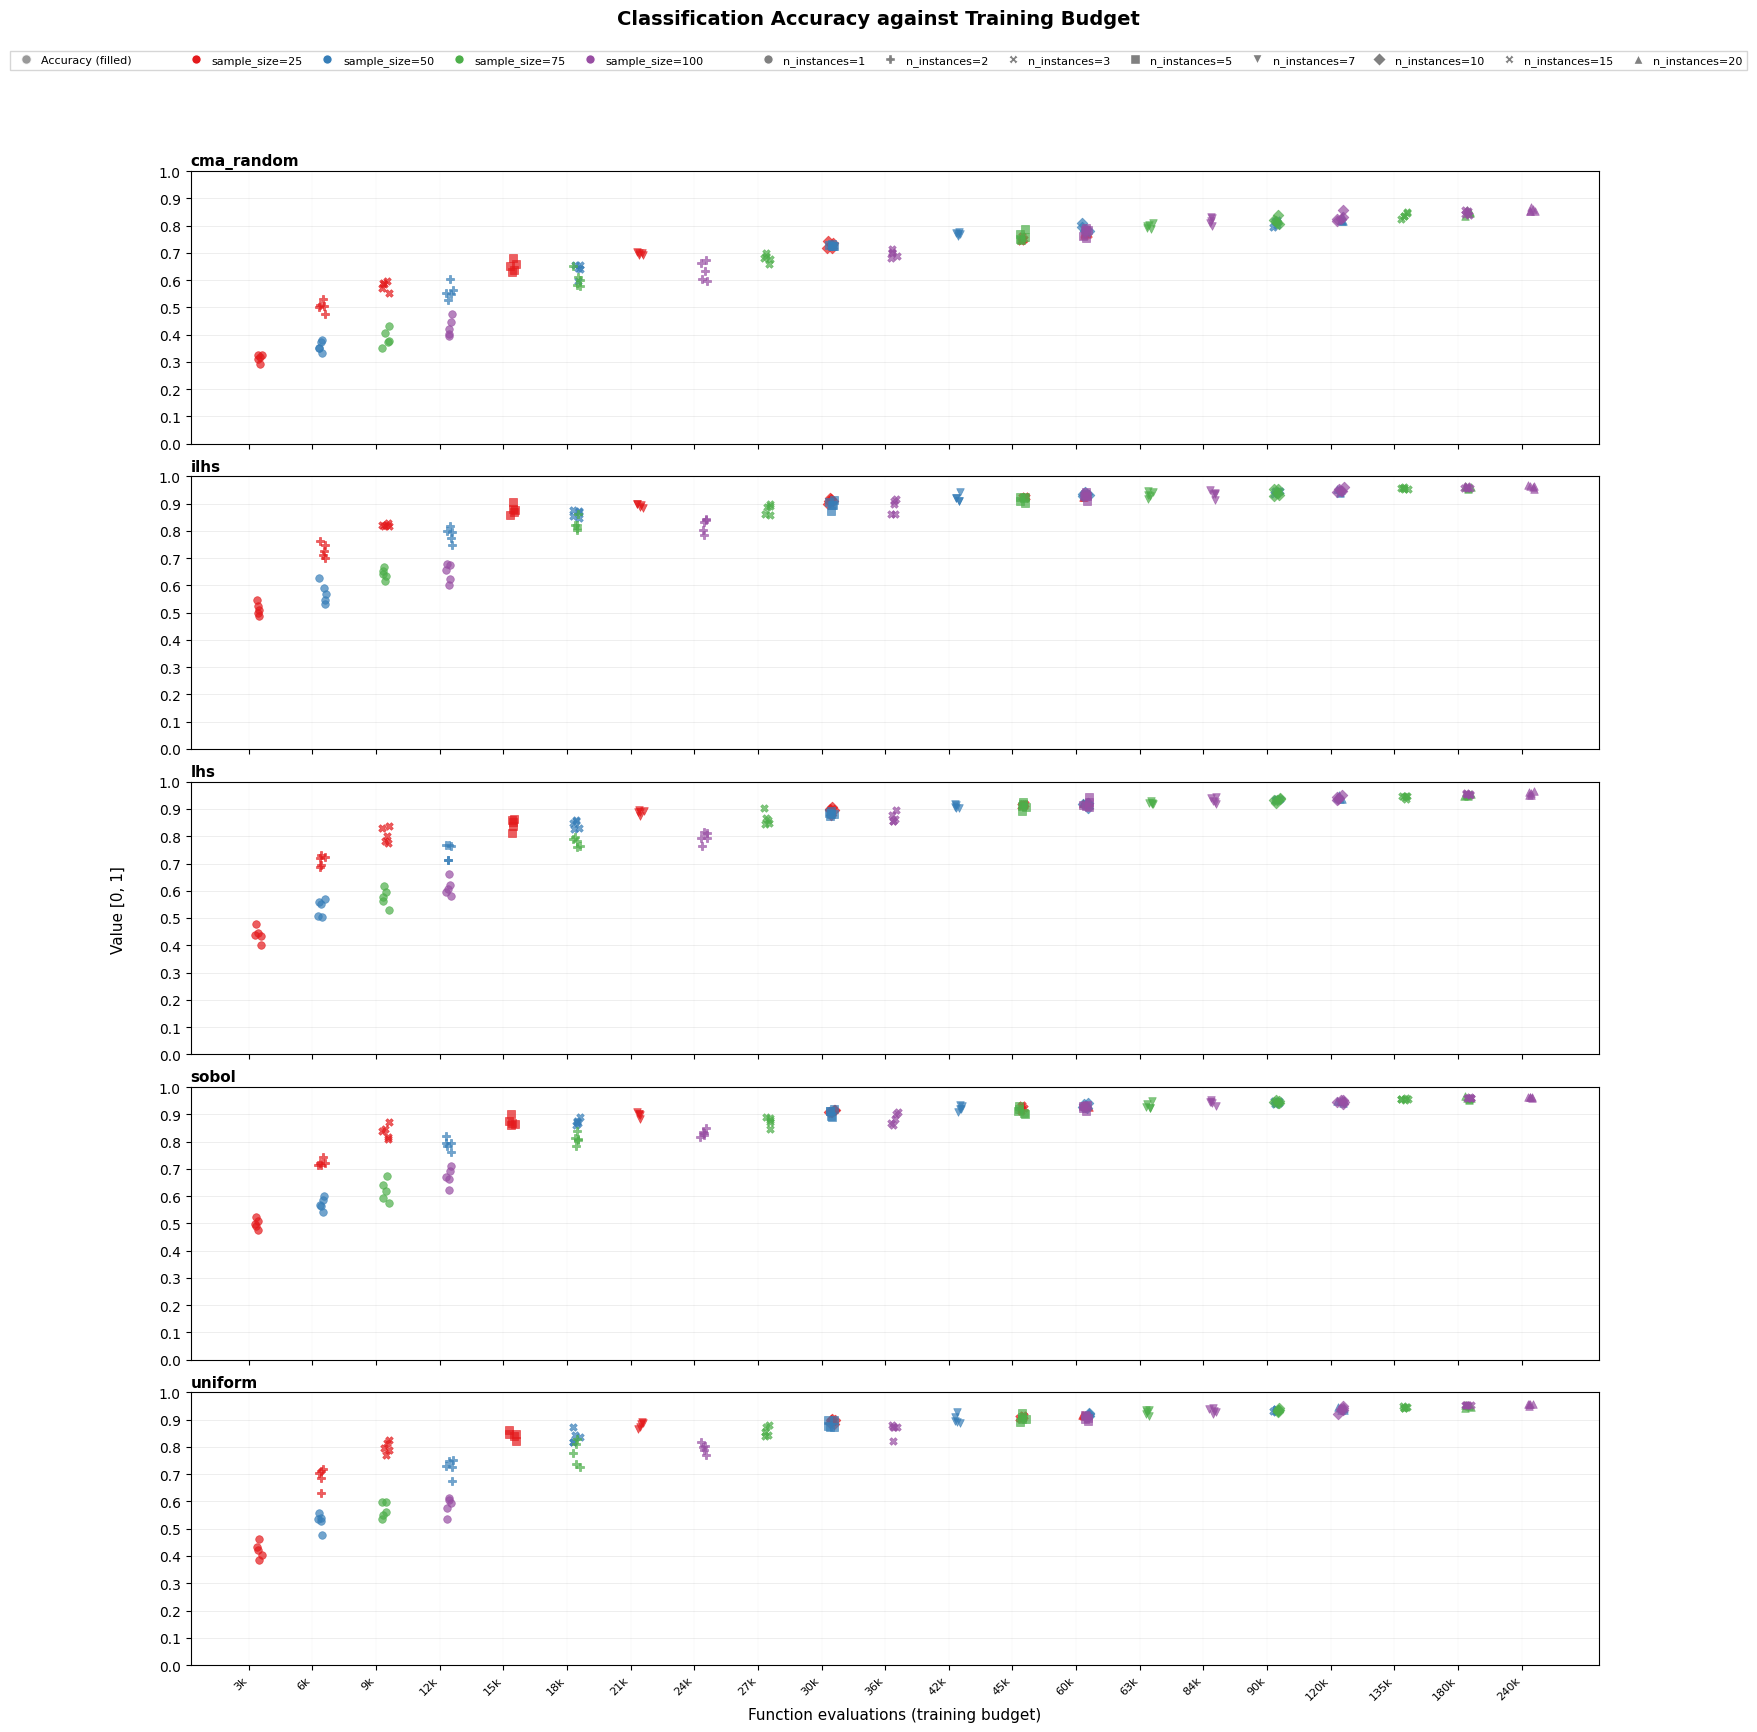

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [5]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.n_runs_train == 1])


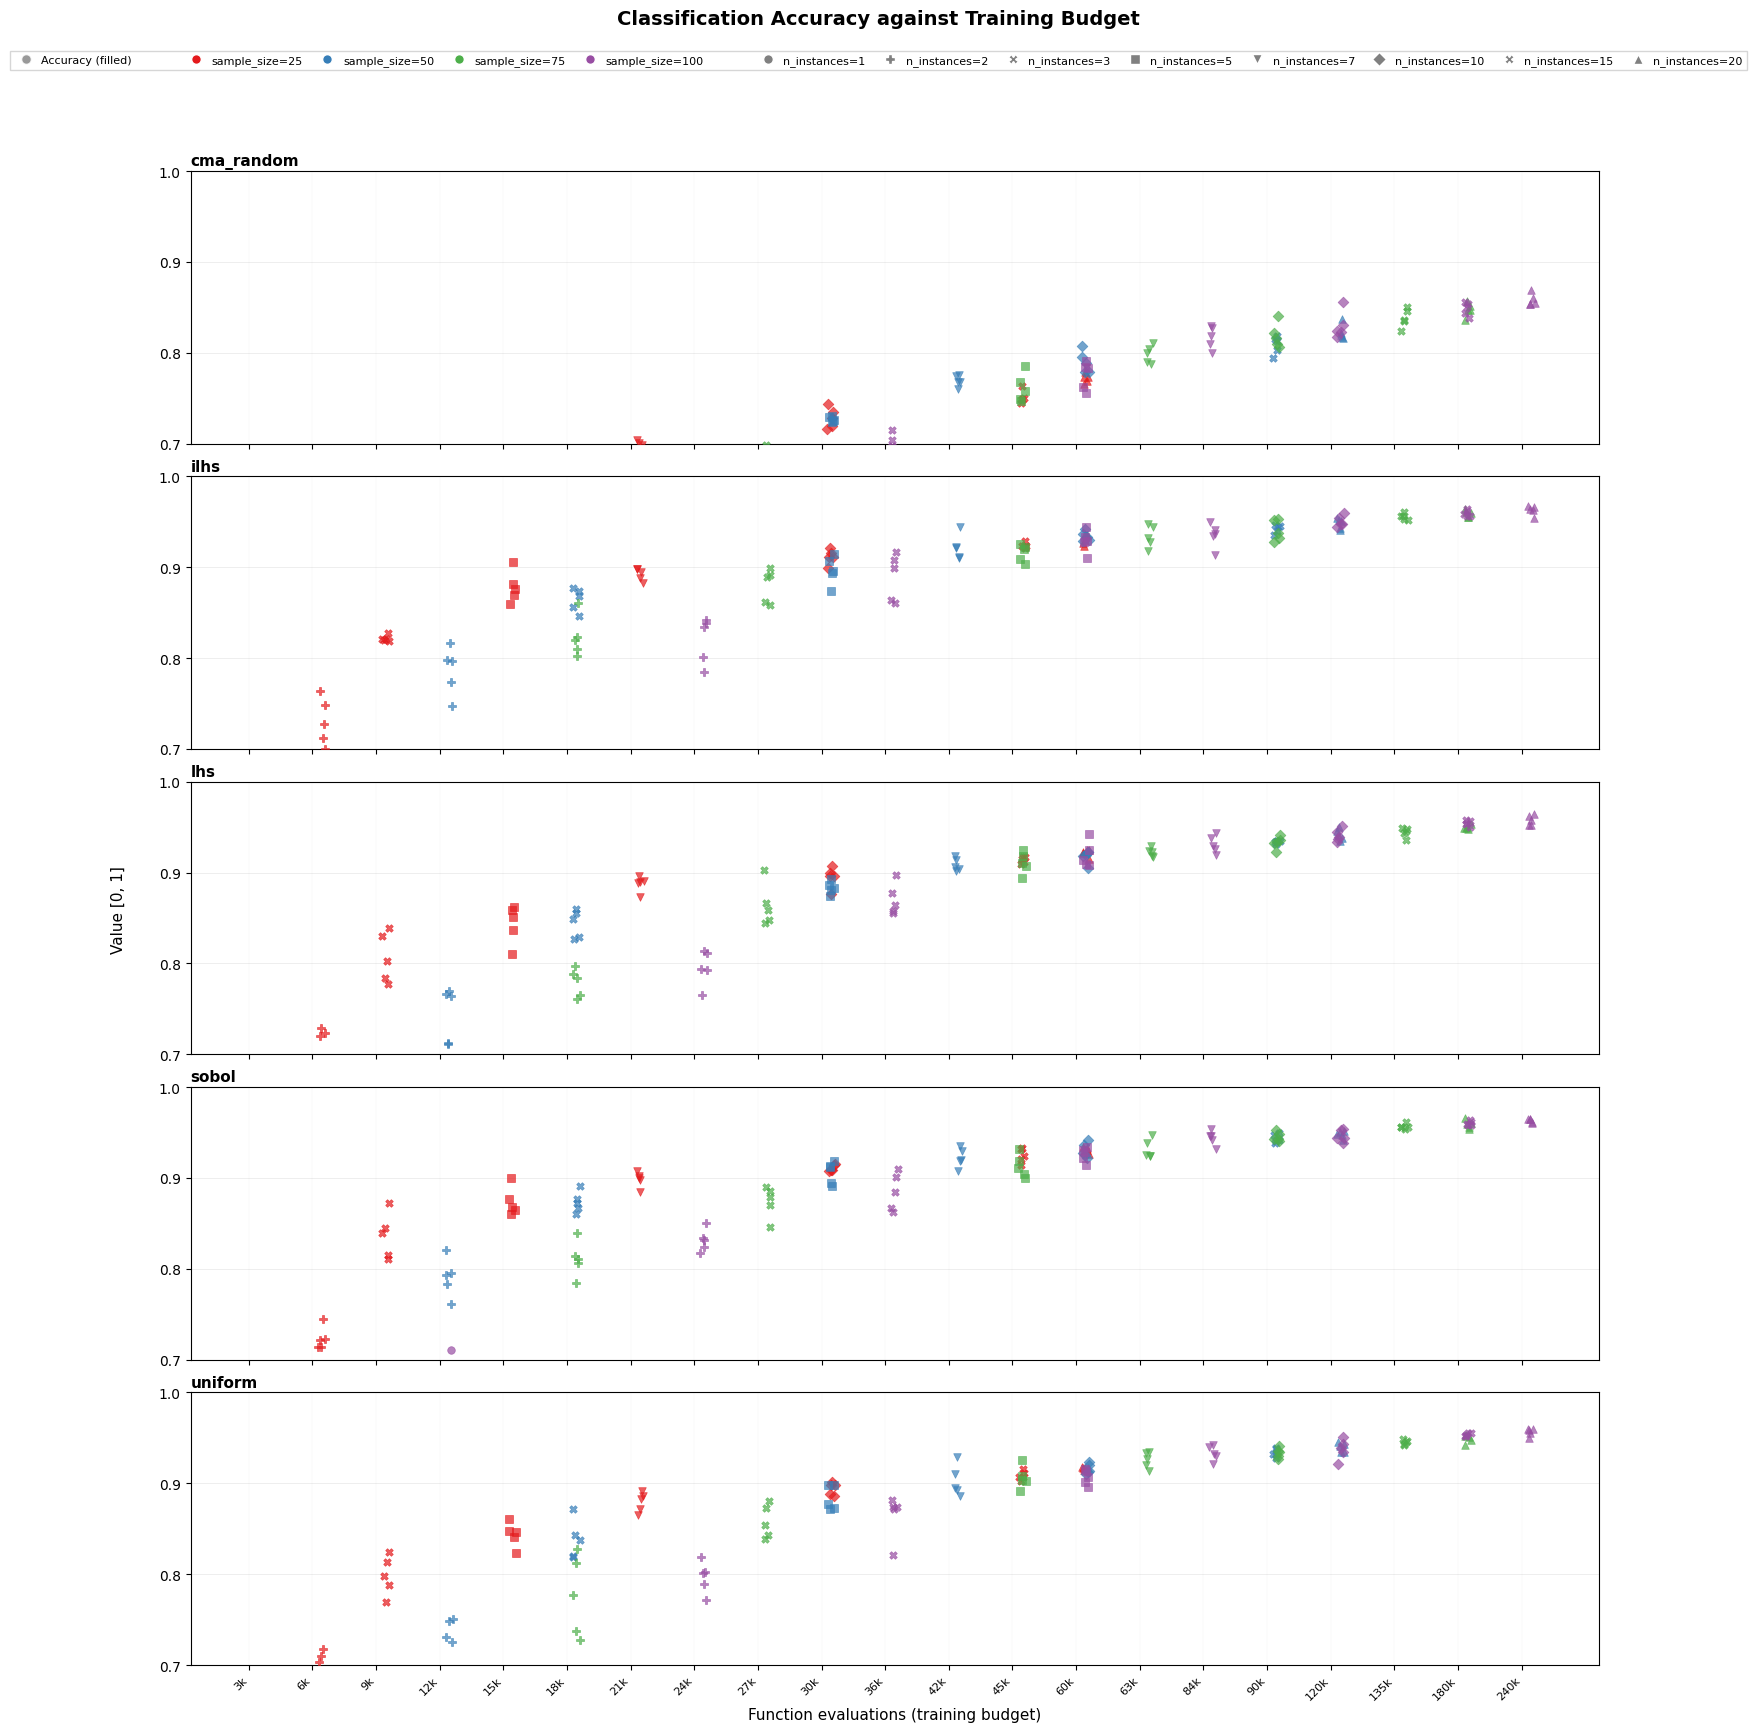

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [6]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7, 1.0))

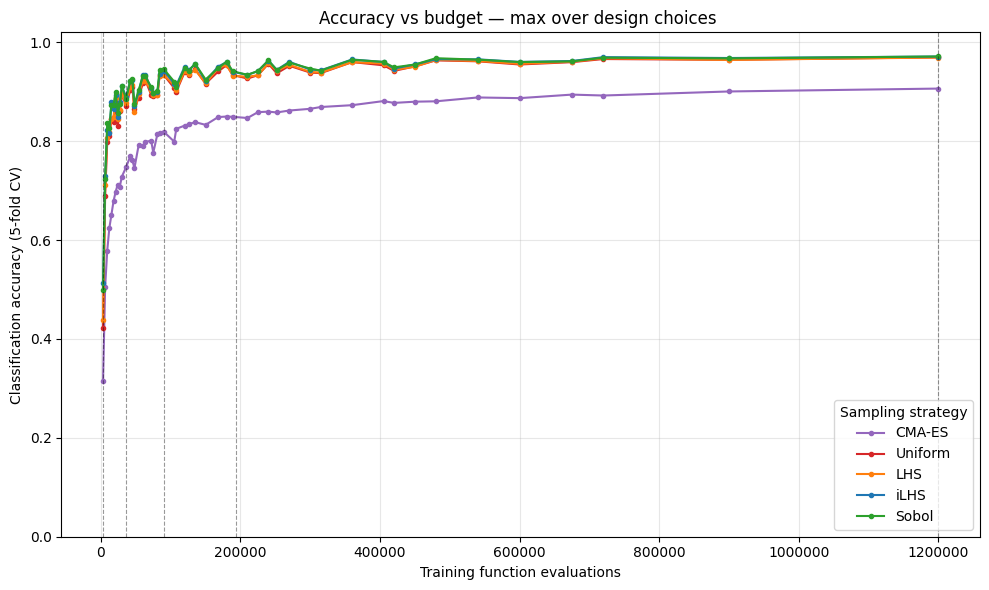

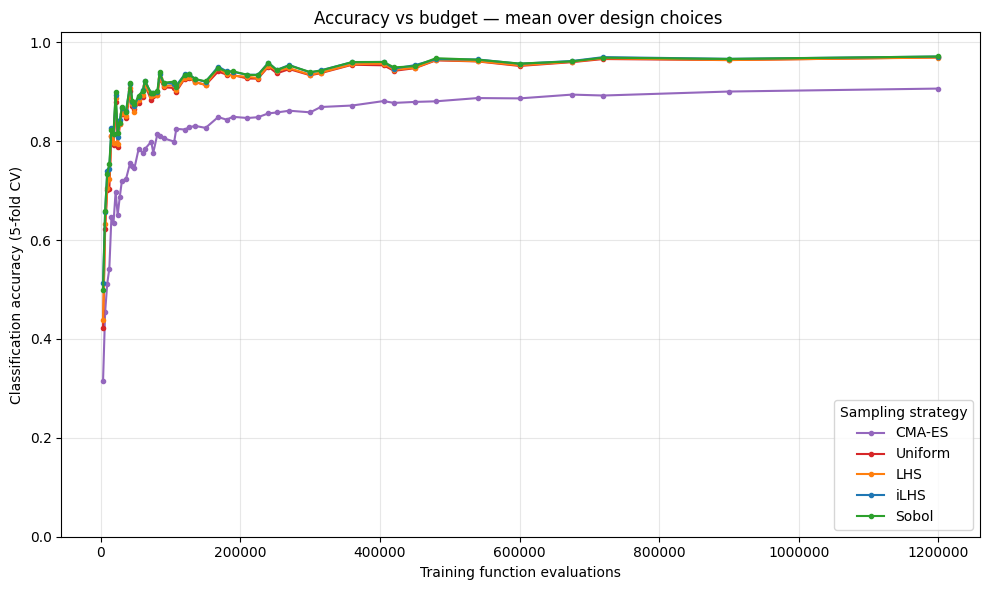

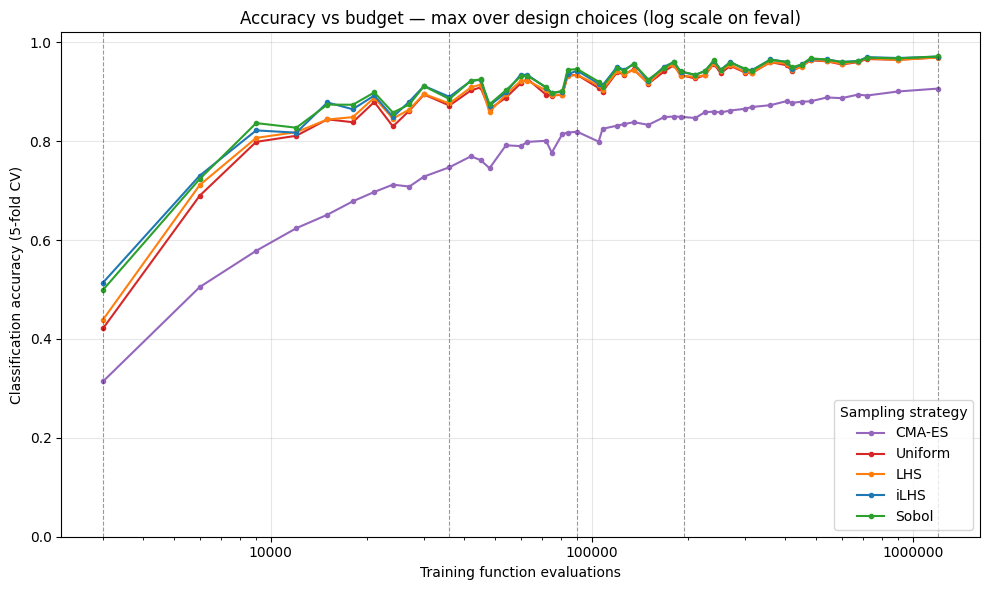

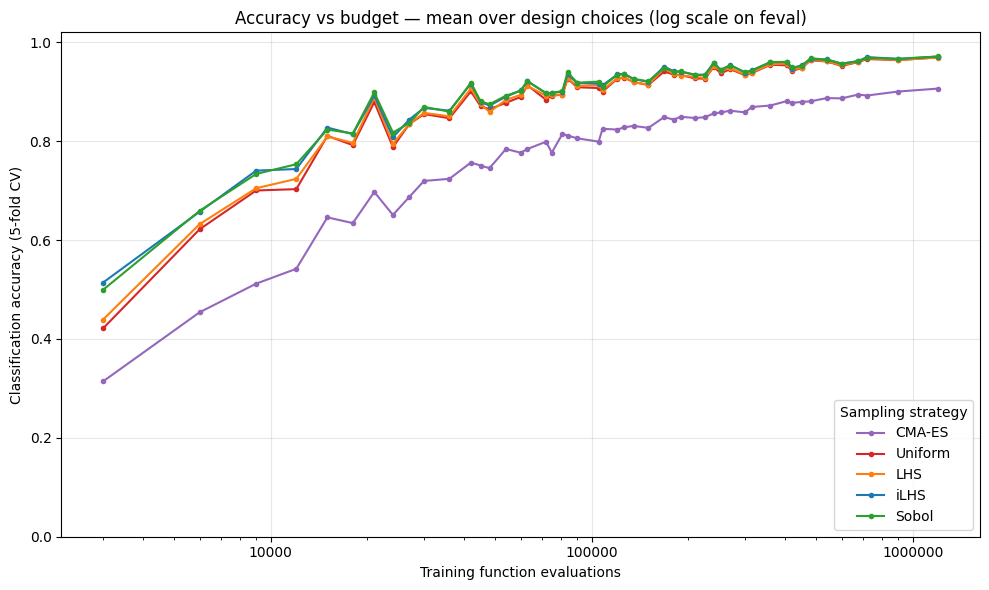

In [7]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)

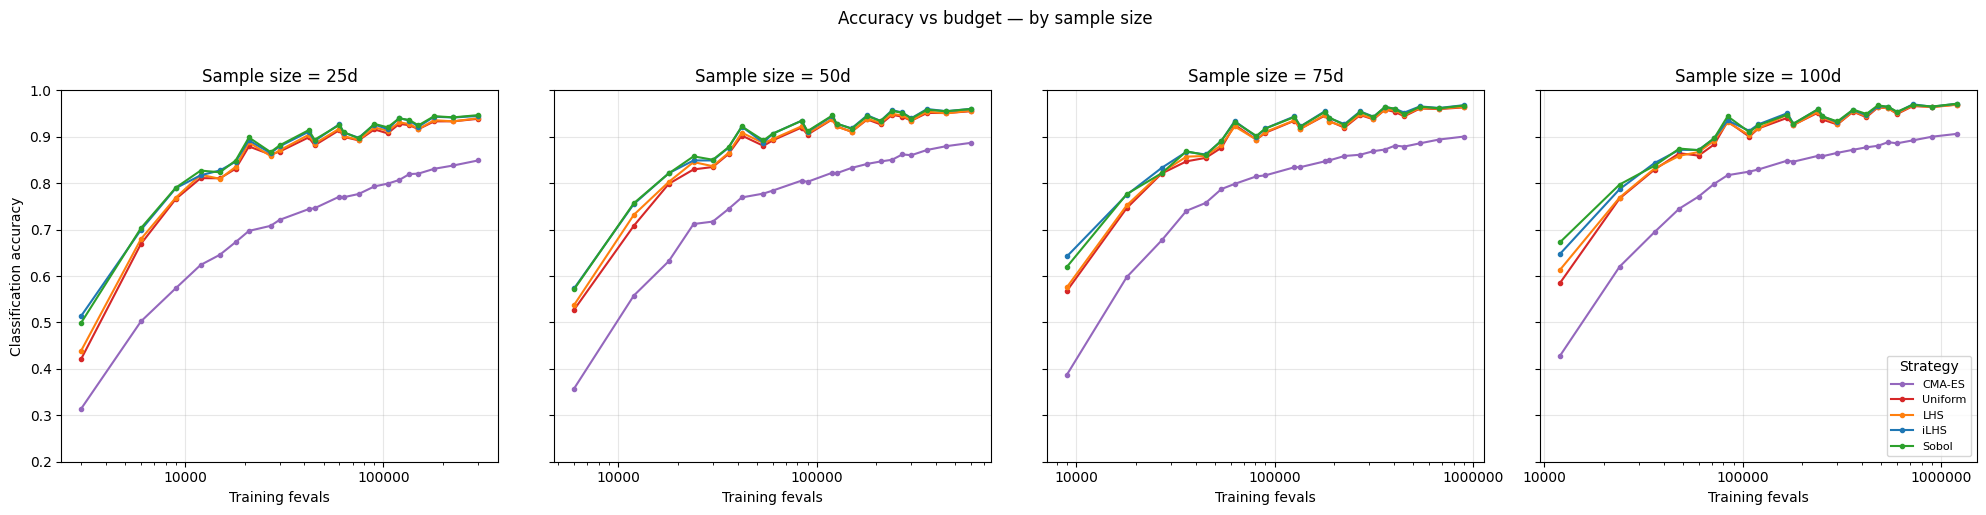

In [8]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))


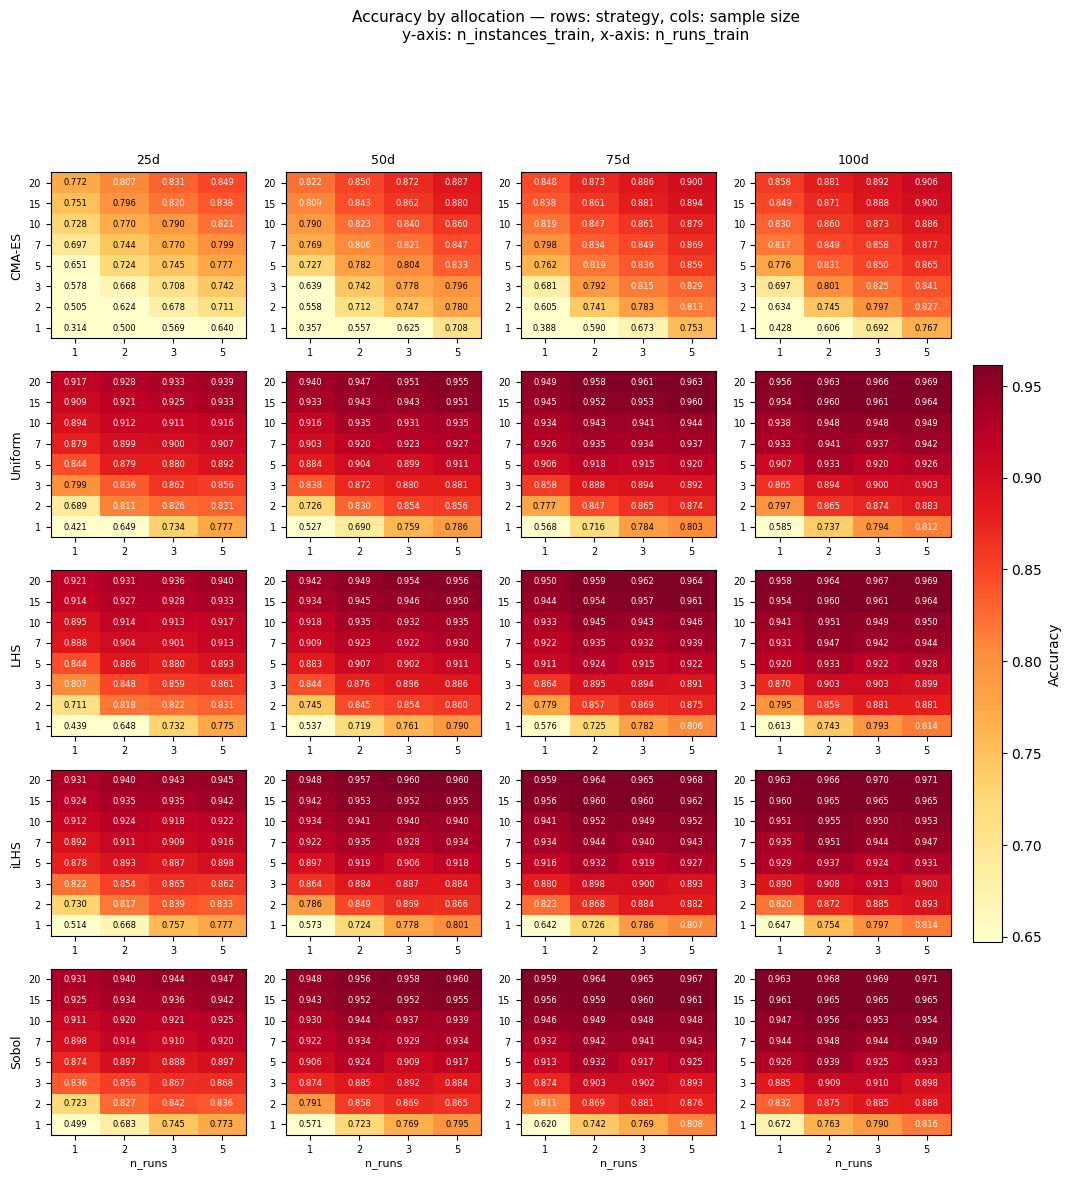

In [9]:
plot_allocation_heatmaps(fold_agg_df)


Budget tiers (4):
  (2999.999, 36000.0]: 180 configs
  (36000.0, 90000.0]: 170 configs
  (90000.0, 194250.0]: 130 configs
  (194250.0, 1200000.0]: 160 configs

          budget_tier              factor factor_label   eta_sq  marginal_range  n_rows  n_levels
  (2999.999, 36000.0]   sampling_strategy     Strategy 0.296883        0.175871     180         5
  (2999.999, 36000.0] sample_size_per_dim  Sample size 0.005569        0.021242     180         4
  (2999.999, 36000.0]   n_instances_train    Instances 0.358429        0.201473     180         6
  (2999.999, 36000.0]        n_runs_train         Runs 0.032444        0.048782     180         4
   (36000.0, 90000.0]   sampling_strategy     Strategy 0.712423        0.121600     170         5
   (36000.0, 90000.0] sample_size_per_dim  Sample size 0.009666        0.016458     170         4
   (36000.0, 90000.0]   n_instances_train    Instances 0.191339        0.099623     170         8
   (36000.0, 90000.0]        n_runs_train         Runs 0

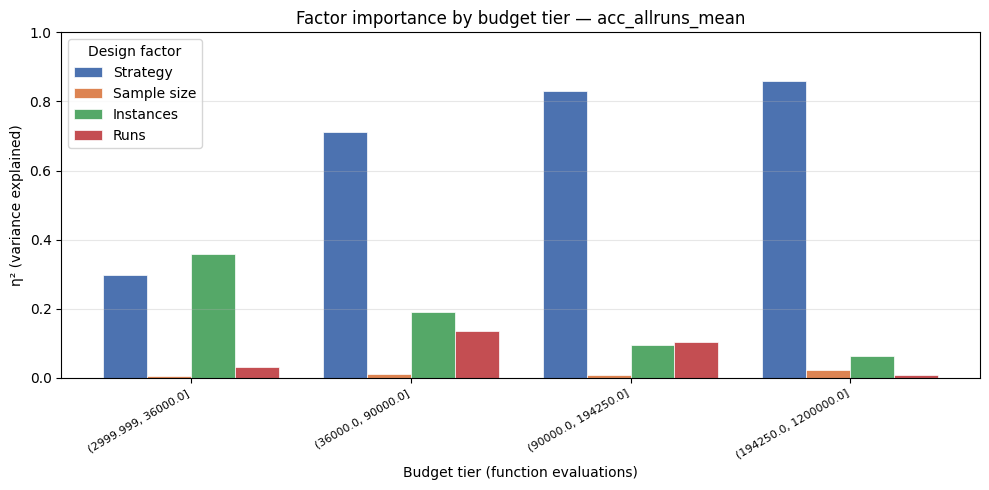

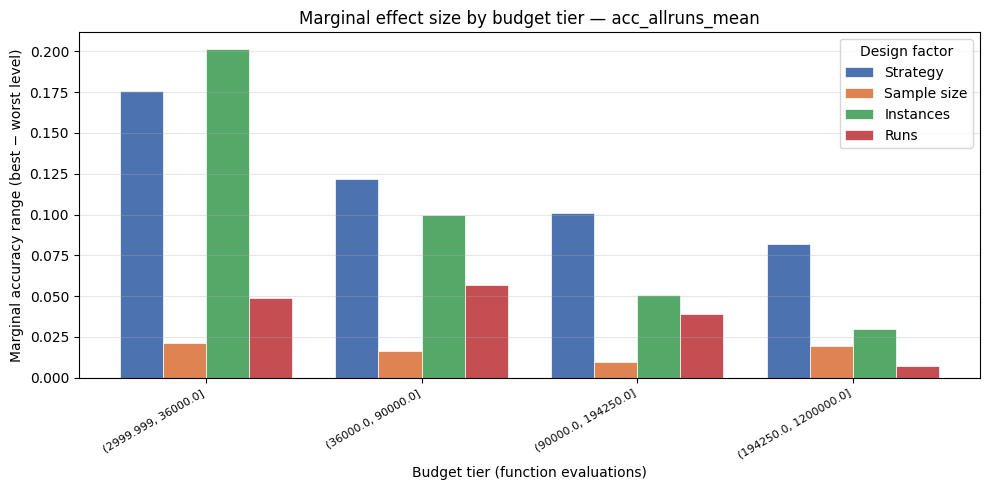

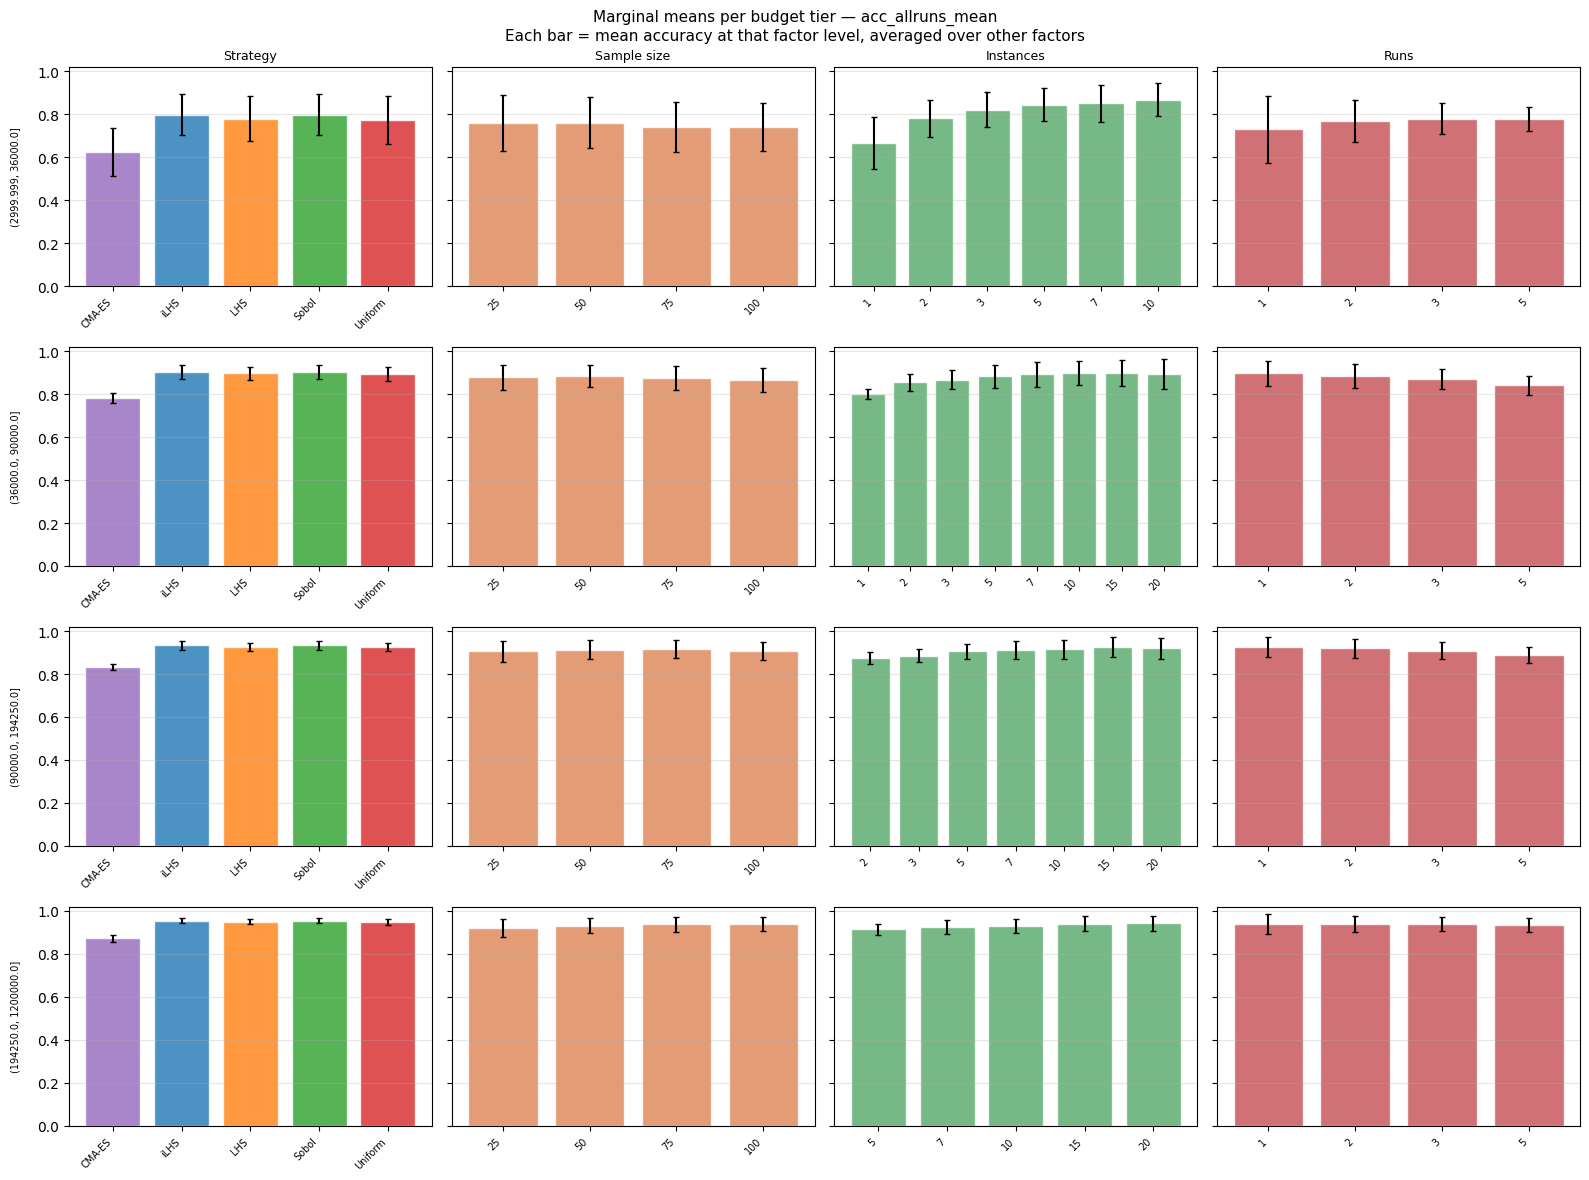

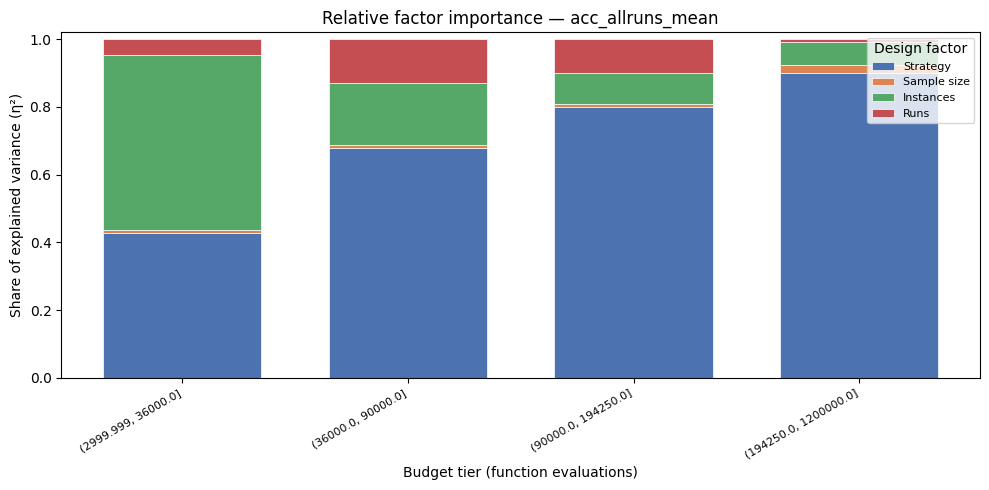

In [10]:
from rq2_factor_importance import *
imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

Pair-level data (20 strategy×size combos):
sampling_strategy  sample_size_per_dim       cv  acc_mean  acc_std  n_configs
       cma_random                   25 0.358806  0.709916 0.117193         32
       cma_random                   50 0.384086  0.766421 0.113752         32
       cma_random                   75 0.398968  0.796087 0.108124         32
       cma_random                  100 0.428547  0.808637 0.102075         32
             ilhs                   25 0.231247  0.865344 0.093104         32
             ilhs                   50 0.177530  0.890860 0.082859         32
             ilhs                   75 0.151934  0.904146 0.075052         32
             ilhs                  100 0.130748  0.910100 0.072866         32
              lhs                   25 0.264961  0.853998 0.103501         32
              lhs                   50 0.213222  0.880855 0.088564         32
              lhs                   75 0.192445  0.894747 0.083364         32
              lhs    

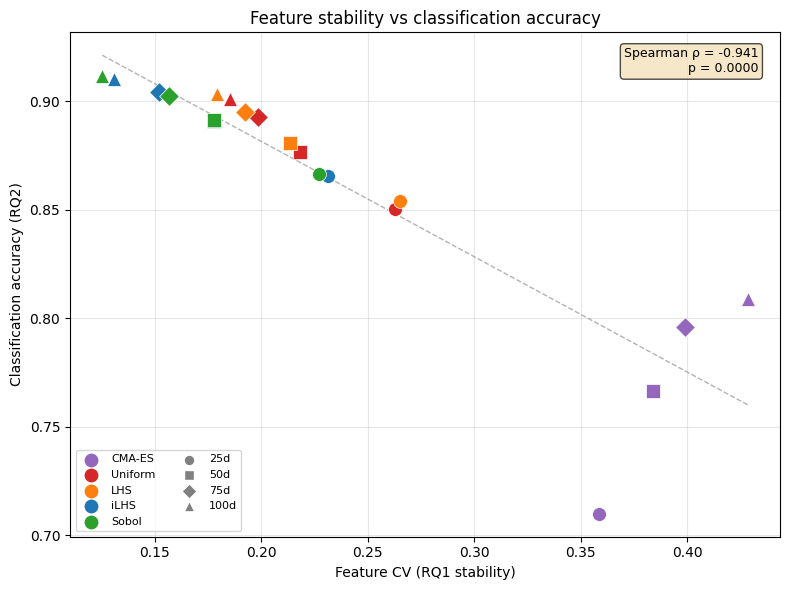

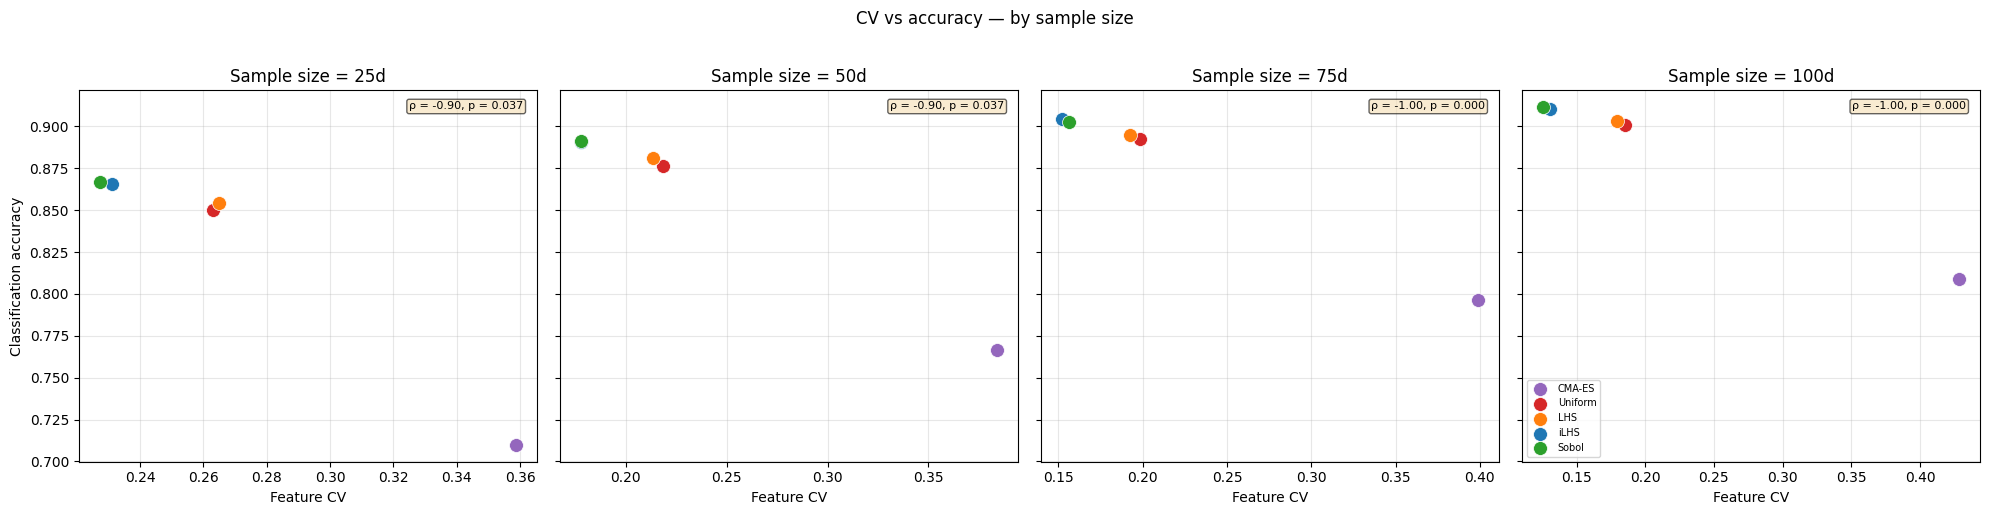

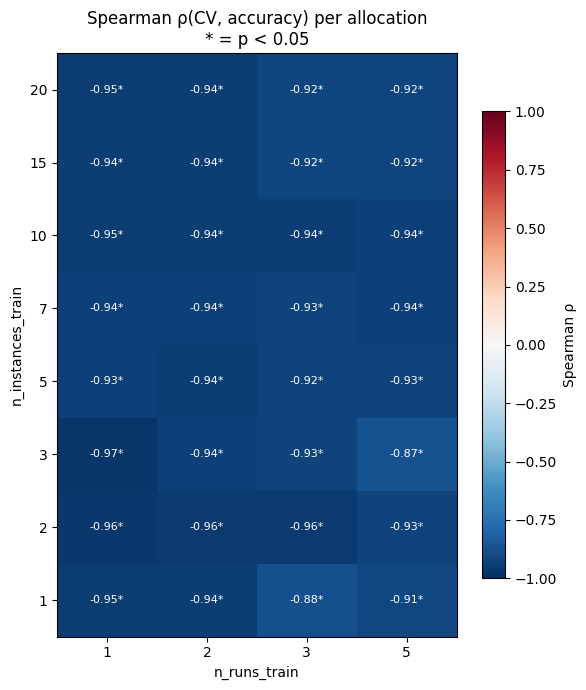


Partial correlation analysis:
        analysis     controlling_for   n  spearman_rho      p_value
             Raw                   — 640     -0.499618 1.032220e-41
         Partial sample_size_per_dim 640     -0.415164 4.668020e-28
         Partial       n_feval_train 640     -0.465986 8.188860e-36
 Within size=25d        (stratified) 160     -0.434123 9.742612e-09
 Within size=50d        (stratified) 160     -0.419292 3.418459e-08
 Within size=75d        (stratified) 160     -0.396950 2.027318e-07
Within size=100d        (stratified) 160     -0.390491 3.311820e-07



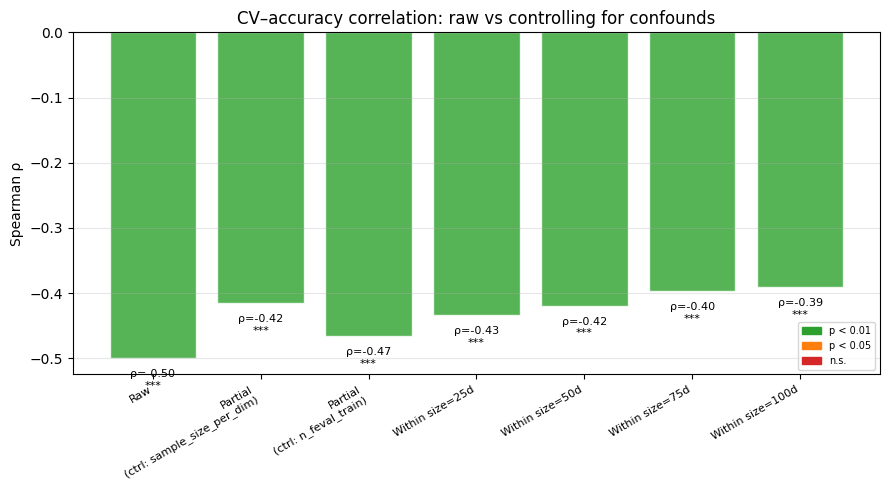

Full correlation summary:
      level level_value   n  spearman_rho      p_value
     global         all 640     -0.499618 1.032220e-41
sample_size          25 160     -0.434123 9.742612e-09
sample_size          50 160     -0.419292 3.418459e-08
sample_size          75 160     -0.396950 2.027318e-07
sample_size         100 160     -0.390491 3.311820e-07
 allocation  1inst_1run  20     -0.951880 1.102808e-10
 allocation  1inst_2run  20     -0.941353 6.293603e-10
 allocation  1inst_3run  20     -0.881203 2.886085e-07
 allocation  1inst_5run  20     -0.912782 2.014186e-08
 allocation  2inst_1run  20     -0.962406 1.242703e-11
 allocation  2inst_2run  20     -0.957895 3.389667e-11
 allocation  2inst_3run  20     -0.956391 4.622989e-11
 allocation  2inst_5run  20     -0.926316 4.644140e-09
 allocation  3inst_1run  20     -0.972932 6.714944e-13
 allocation  3inst_2run  20     -0.936842 1.205937e-09
 allocation  3inst_3run  20     -0.926316 4.644140e-09
 allocation  3inst_5run  20     -0.8721

(          level  level_value    n  spearman_rho       p_value
 0        global          all  640     -0.499618  1.032220e-41
 1   sample_size           25  160     -0.434123  9.742612e-09
 2   sample_size           50  160     -0.419292  3.418459e-08
 3   sample_size           75  160     -0.396950  2.027318e-07
 4   sample_size          100  160     -0.390491  3.311820e-07
 5    allocation   1inst_1run   20     -0.951880  1.102808e-10
 6    allocation   1inst_2run   20     -0.941353  6.293603e-10
 7    allocation   1inst_3run   20     -0.881203  2.886085e-07
 8    allocation   1inst_5run   20     -0.912782  2.014186e-08
 9    allocation   2inst_1run   20     -0.962406  1.242703e-11
 10   allocation   2inst_2run   20     -0.957895  3.389667e-11
 11   allocation   2inst_3run   20     -0.956391  4.622989e-11
 12   allocation   2inst_5run   20     -0.926316  4.644140e-09
 13   allocation   3inst_1run   20     -0.972932  6.714944e-13
 14   allocation   3inst_2run   20     -0.936842  1.205

In [11]:
from rq2_cv_accuracy import *
run_all(fold_agg_df, cv_col="cv_instance_median_mean",
                               acc_col="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Saturation curves for Strategy ...


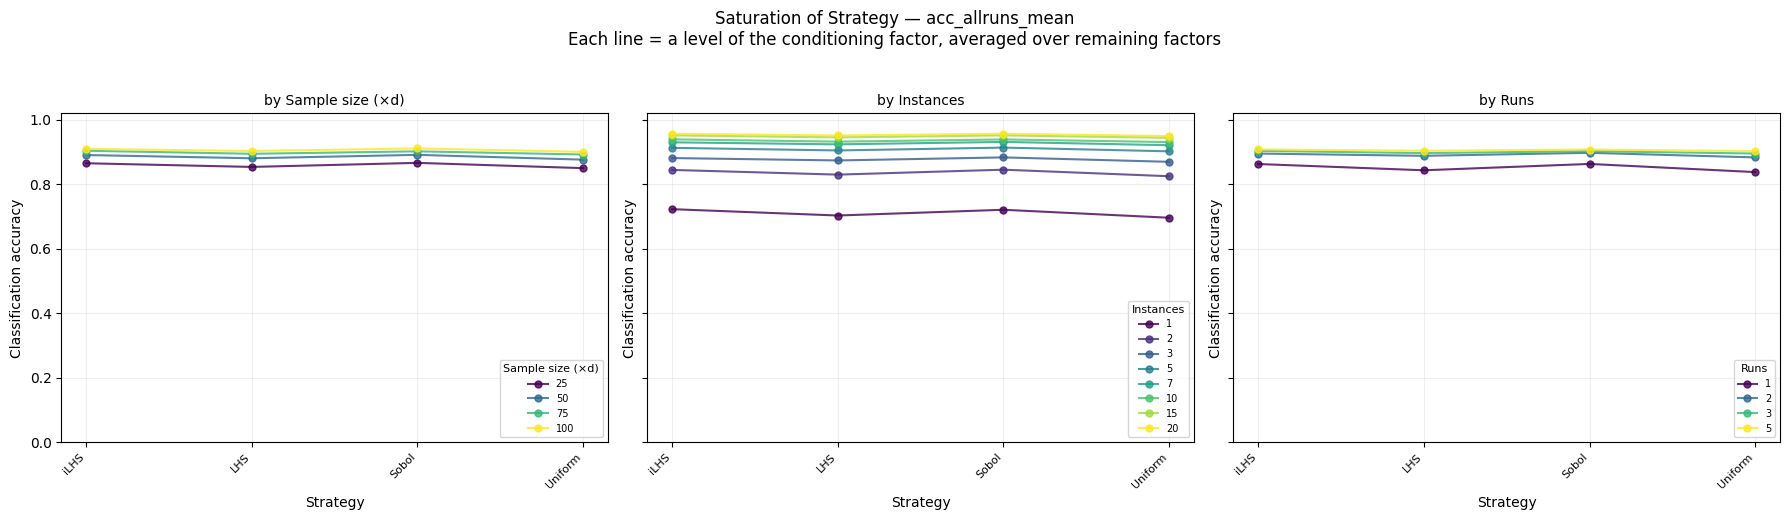

Saturation curves for Sample size (×d) ...


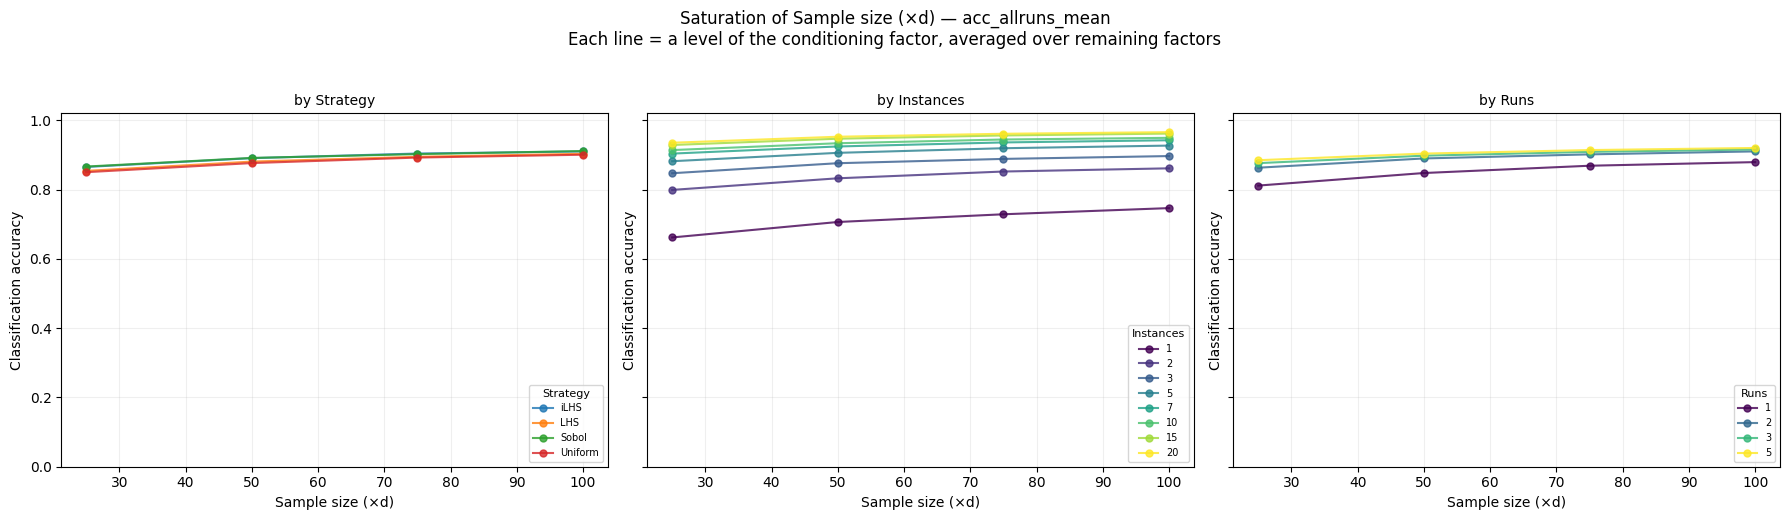

Saturation curves for Instances ...


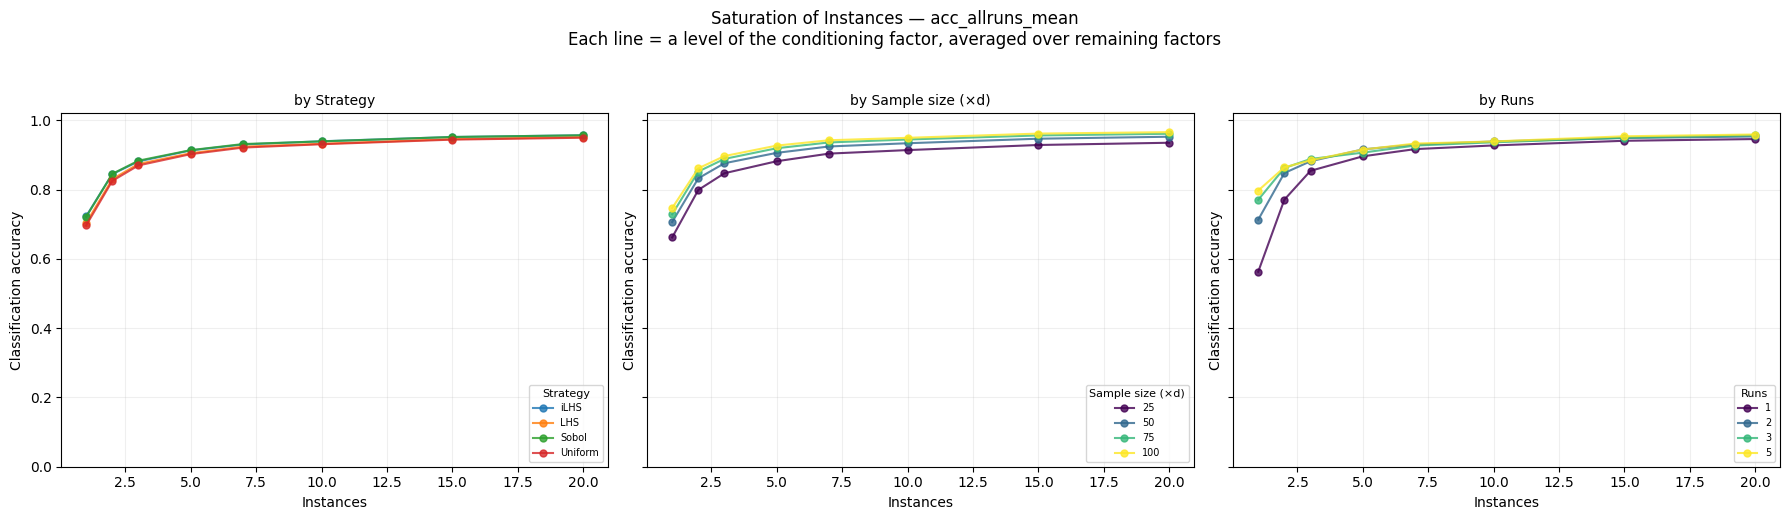

Saturation curves for Runs ...


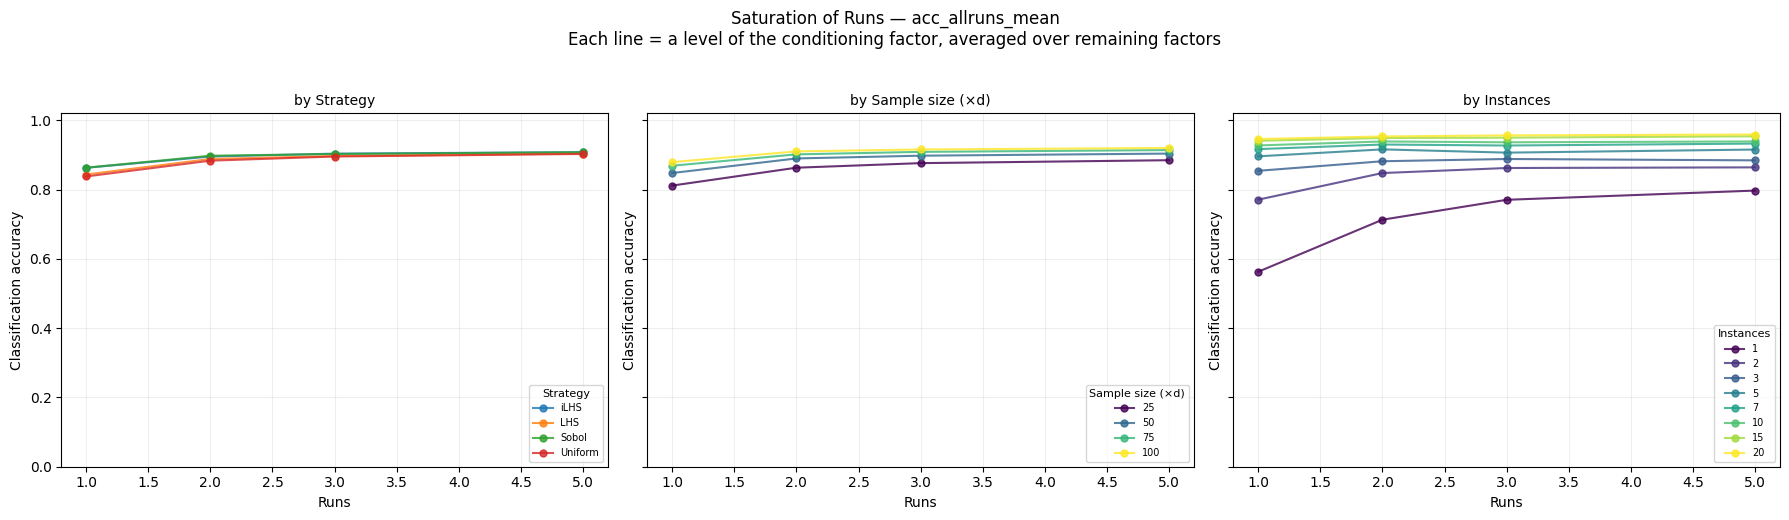

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.025890    0.047396          54.625561
Sample size (×d)          50        75   0.013500    0.047396          28.483558
Sample size (×d)          75       100   0.008006    0.047396          16.890881
       Instances           1         2   0.125416    0.242805          51.653069
       Instances           2         3   0.040887    0.242805          16.839464
       Instances           3         5   0.031413    0.242805          12.937444
       Instances           5         7   0.018135    0.242805           7.469007
       Instances           7        10   0.008730    0.242805           3.595677
       Instances          10        15   0.012924    0.242805           5.322974
       Instances          15        20   0.005299    0.242805           2.182365
            Runs           1         2   0.039353    0.053855          73.072870


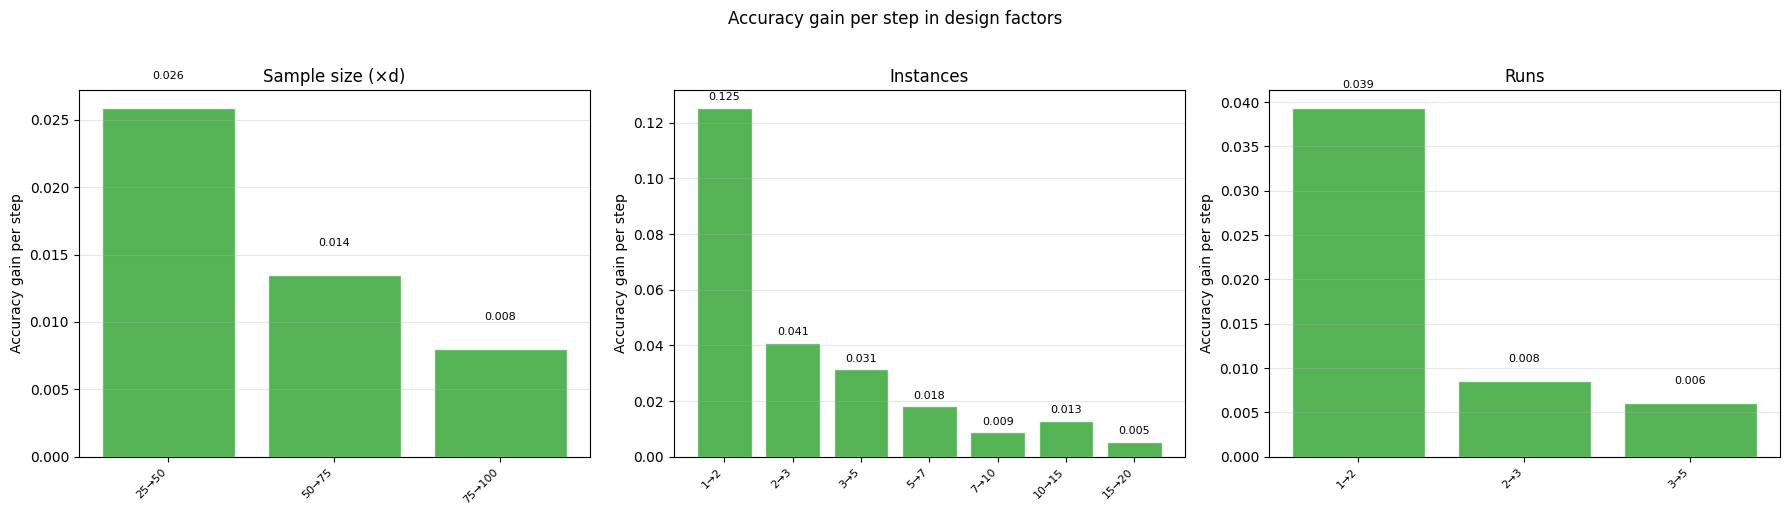

In [12]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

In [13]:
from rq2_rf_impurity_importance import *
input_df = fold_agg_df[fold_agg_df["sampling_strategy"] != "cma_random"]
results_imp, summary_imp, metrics_df = run_stratified_impurity_importance(
    input_df,
    hyperparams=["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

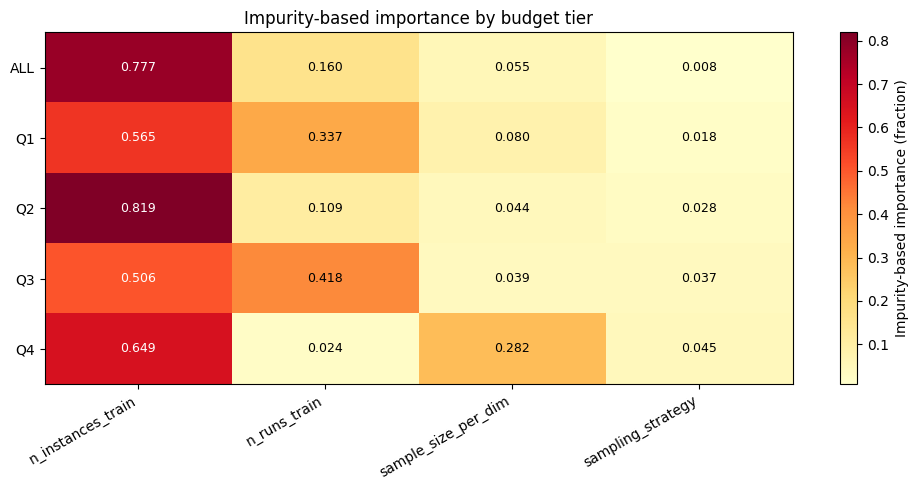

In [14]:
plot_importance_heatmap(summary_imp)
plt.show()


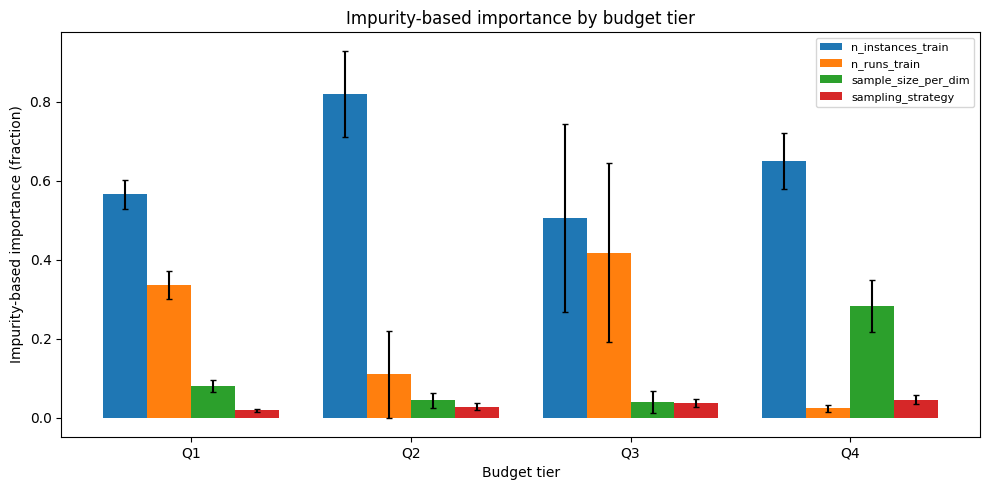

In [15]:
plot_importance_bars(results_imp)
plt.show()


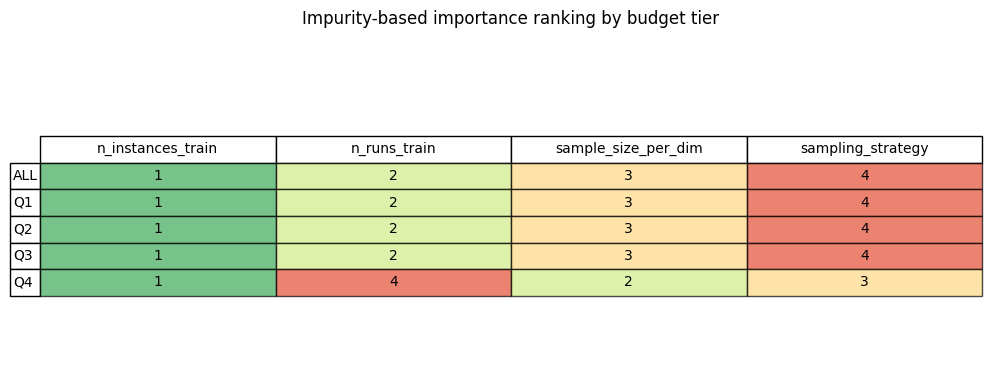

In [16]:
plot_rank_table(results_imp)
plt.show()


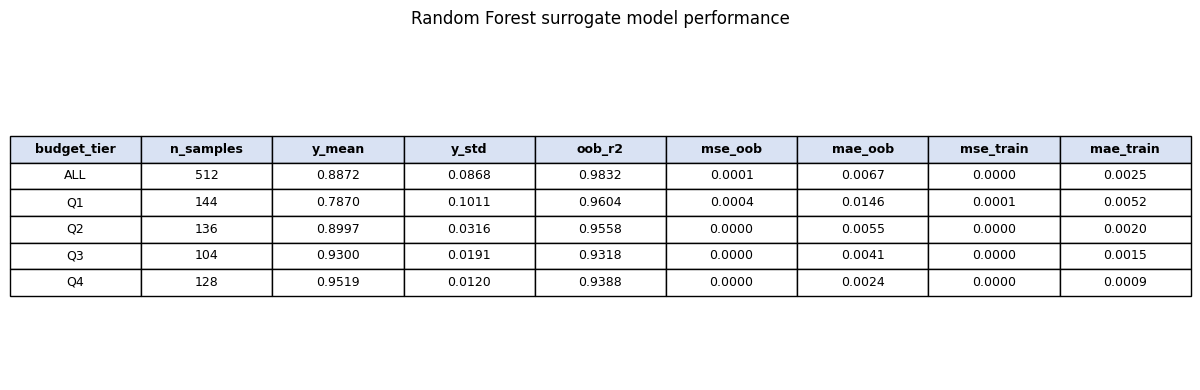

In [17]:
plot_metrics_table(metrics_df)
plt.show()


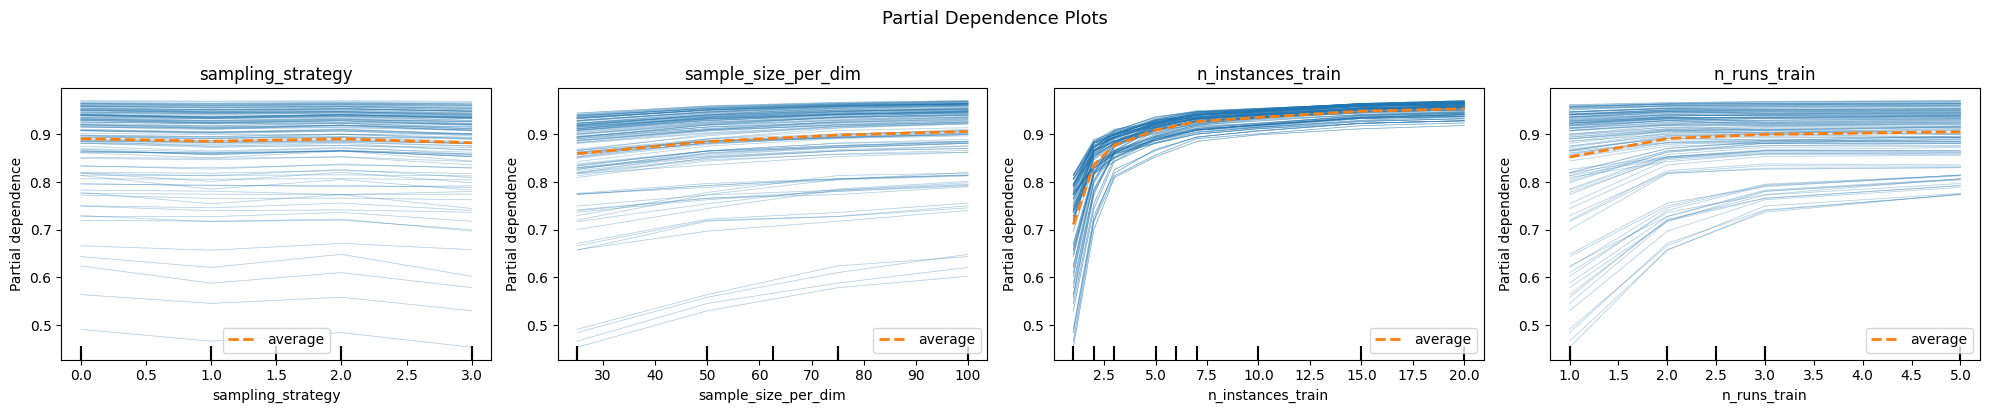

In [18]:
plot_pdp_individual(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], target="acc_allruns_mean")
plt.show()

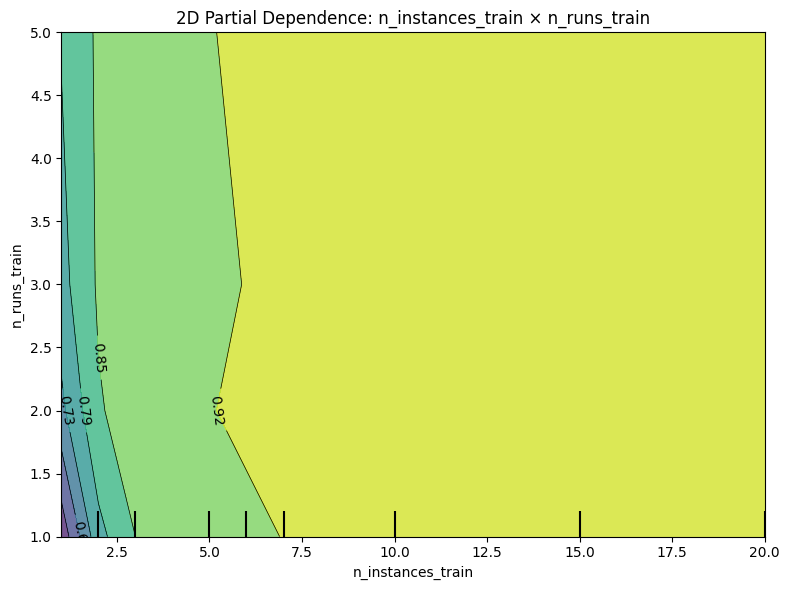

In [19]:
plot_pdp_2d(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"))
plt.show()

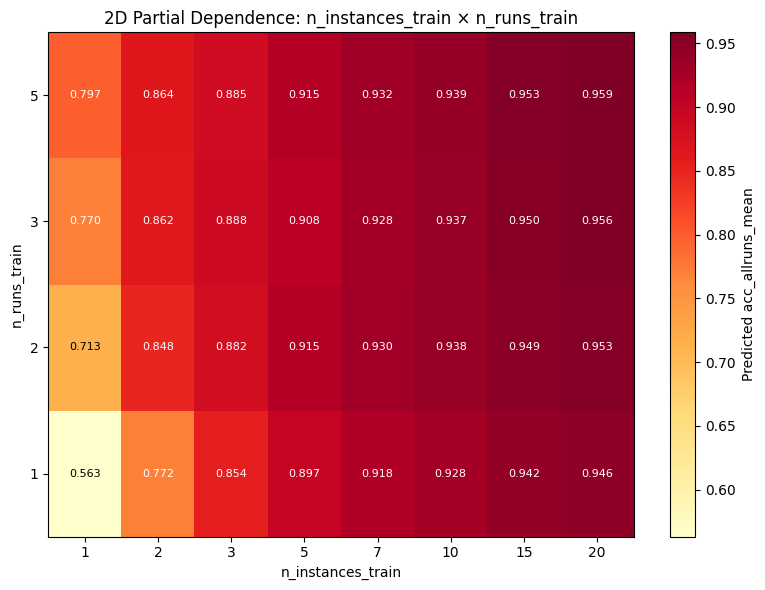

In [20]:
plot_pdp_2d_heatmap(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean",
            annotate=True)
plt.show()

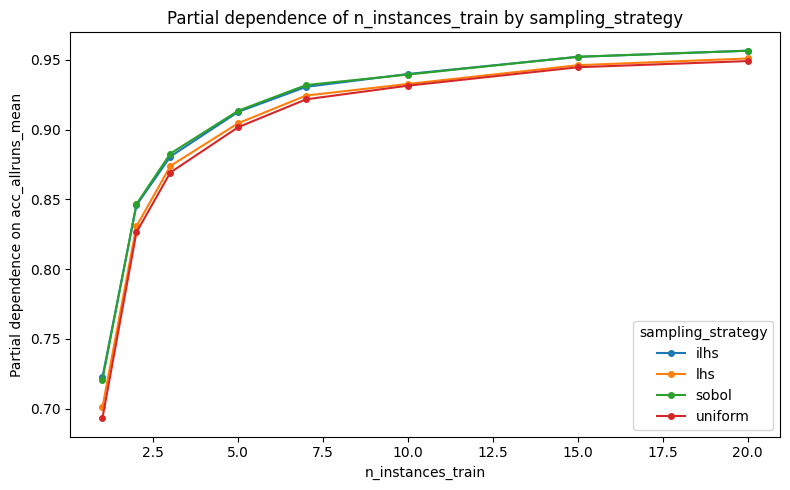

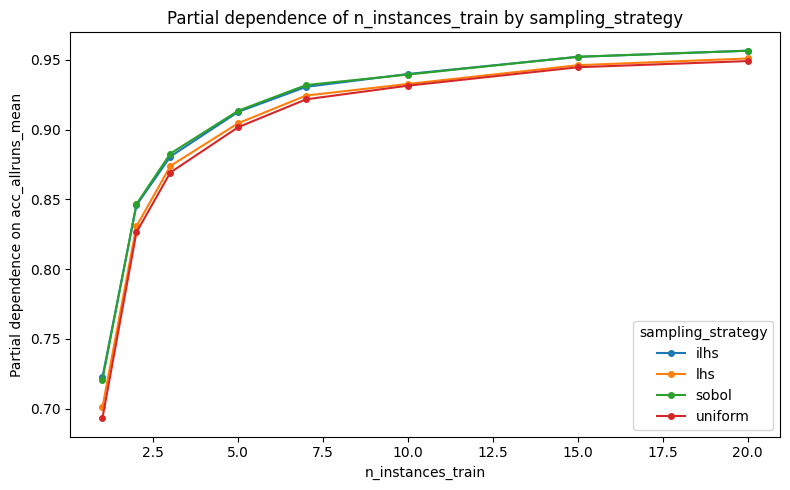

In [21]:
plot_pdp_by_strategy(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_instances_train")

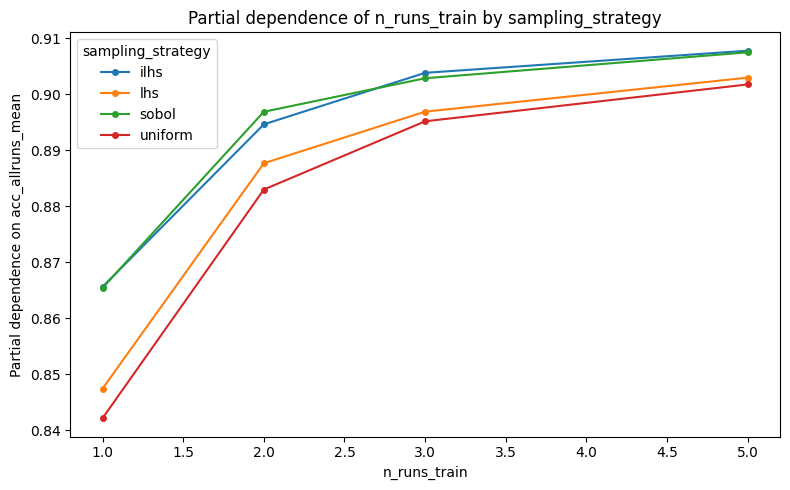

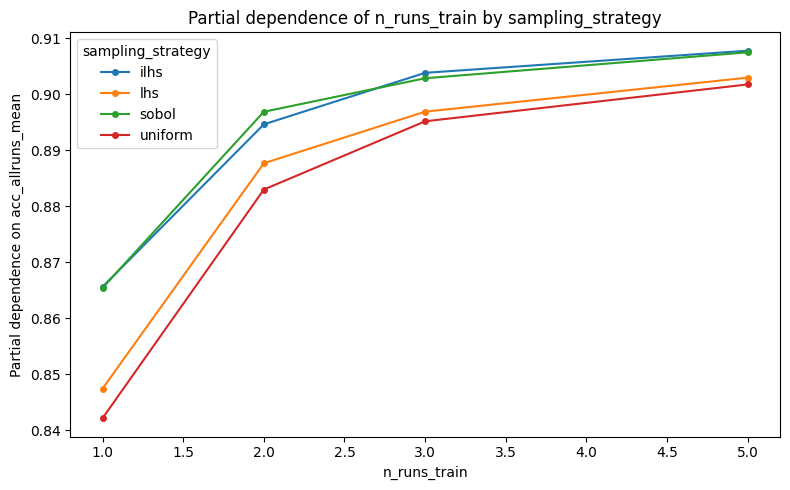

In [22]:
plot_pdp_by_strategy(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_runs_train")